# <center><h2><b> <span style="color:blue">КУРСОВАЯ РАБОТА АССН</span></h2></b>    

%matplotlib widget

# Глава №1
[Назад в СОДЕРЖАНИЕ](#Содержание)

## <span style="color:blue">Создайте диаграммы направленности заданную функцией F(ε) </span>   

Для РЛС, осуществляющей обзор по азимуту, диаграмма направленности антенны может быть описана следующей функцией:


$$
F(ε)=
\begin {cases}
1 - \frac{ε_{min} - ε}{ε}, &\text{при 0 < ε < ε$_{min}$}\\
1, &\text{при ε$_{min}$ < ε < ε$_0$}\\
\sin(ε_0)cosec(ε), &\text{при ε$_0$ < ε < ε$_{max}$}\\
0, &\text{при ε$_{max}$ < ε < 90°}
\end {cases}
$$

Диаграмма направленности антенны, построенная с помощью функции, для заданных значений:
   - минимального значения угла ε$_{min}$
   - максимального значения угла ε$_{max}$
   - значения характеристического угла ε$_{0}$

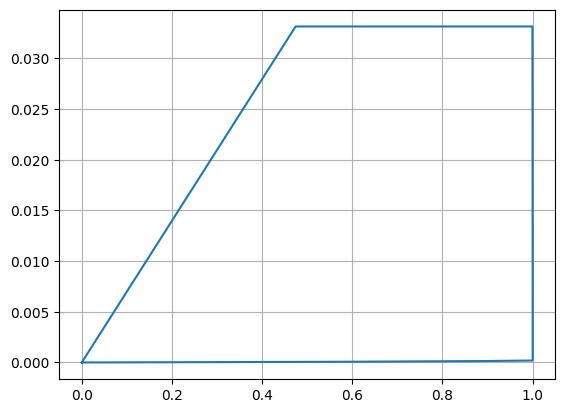

In [1]:
from numpy import sin, cos, radians
import matplotlib.pyplot as plt

#Ввод пользовательских данных 
# раздел диаграмма направленности
e_min = radians(0.01)
e0 = radians(1.9)
e_max = radians(4)

#-----------------------------
x=[]
y=[]
for e_g  in range(1, 90000, 1):
    e = radians(e_g/1000)
    if 0 < e and e < e_min:
        x_t=(1 - ((e_min-e)/e))*cos(e)
        if x_t >=0:
            x.append(x_t)
            y.append((1 - ((e_min-e)/e))*sin(e))
    elif e_min < e and e < e0:
        x.append(1*cos(e))
        y.append(1*sin(e))
    elif e0 <= e and e < e_max:
        x.append((sin(e0)*(1/sin(e)))*cos(e))
        y.append((sin(e0)*(1/sin(e)))*sin(e))
    elif e_max < e and e < radians(90):
        x.append(0)
        y.append(0)
plt.plot(x, y)
#plt.xlabel("D (м)")
#plt.ylabel("H (м)")
plt.grid()
plt.show()

## <span style="color:blue">Расчет максимальной дальность без учета затуханий </span>  

<span>Выражение для максимальной дальности обнаружения воздушного объекта с заданными величинами вероятностей правильного обнаружения и ложной тревоги воздушного объекта в РЛС с потерями рассчитывается выражением: </span>


### Максимальная дальность обнаружения без потерь

$$
r_{max0} = ^4\sqrt{\frac {2 ∙ p_{ср} ∙ t_н ∙ G_m ∙ \sigma ∙ A_{max прм}}{(4\pi)^2 ∙ a_п ∙ q_0^2 ∙ k_ш ∙ k ∙ T}}
$$

$$
P_{cp} - \text{средняя мощность излучения генерируемого сигнала за время наблюдения}\\
t_н - \text{время наблюдения, отраженного от воздушного объекта сигнала}\\
G_m - \text{Максимальлное значение коэффицента усиления передающей антены}\\
A_{max прм} - \text{эффективная площадь приемной антены}\\
\delta - \text{эффективная площадб рассеивания воздушного объекта}\\
a_n - \text{результирующий коэффицент потерь при обработке сигналов}\\
q_0^2 - \text{значение отношения сигнал\шум}\\
k = 1.38*10^{-23}[\frac {Дж}{К}] - \text{постоянная Больцмана}
$$
Все неизвестные переменные будут вычислены ниже:


### Угловая скорость вращения

$$
0_А = \frac {360°}{T_{обз}}
$$
Где: T$_{обз}$ = 10 cек - период обзора
___
### Время наблюдения
$$
t_n = \frac {20_{0.5Раз}}{0_{А}}
$$
Где: 2$0_{0.5Раз}$ - ширина диаграммы направленнности антены по уровню половинной мощности
$\\ 0_{А} - \text{угловая скорость вращения}$

In [2]:

T_obz = 10.0
O_A = 360/T_obz
print("Угловая скорость вращения антенны: " + str(O_A))

dvaO_05raz = 4.8
t_n = (dvaO_05raz)/(O_A)
print("Время наблюдения: " + str(t_n) + " сек")

Угловая скорость вращения антенны: 36.0
Время наблюдения: 0.13333333333333333 сек


### Средняя мощность излучения генерируемого сигнала за время наблюдения
$$
P_{ср} = P_и ∙ r_и ∙ F_п
$$

$Р_и \text{ - импульсная мощность}$
$\\ r_{и} \text{ - длительность импульса}$
$\\ F_{п} \text{ - импульсная мощность}$

In [3]:

F_n = 1000

r_u = 5 /1000000

P_u = 400 *1000

P_cp = F_n*r_u*P_u
print("Средняя мощность излучения генерируемого сигнала за время наблюдения: " + str(P_cp)+" Вт")

Средняя мощность излучения генерируемого сигнала за время наблюдения: 2000.0 Вт


## Значение максимальной эффективной площади приемной антенны
$$
А_{max прм} = v_{прм} ∙ S_{0прм}
$$

$v_{прм} \text{ - коэффицент использования площади приемной антенны}
\\ S_{0прм}\text{ - геометрическая площадь приемной антены}$

In [4]:

v_prm = 0.81

S_0prm = 210
A_max_prm = v_prm * S_0prm 
print("максимальная эффективная площадь приемной антенны " + str(A_max_prm))

максимальная эффективная площадь приемной антенны 170.10000000000002


### Значение максимальной эффективной площади передающей антенны
$$
А_{max перед} = v_{перед} ∙ S_{0перед}
$$

$v_{перед} \text{ - коэффицент использования площади передающей антенны}
\\ S_{0перед}\text{ - геометрическая площадь передающей антены}$
---
### Максимальное значение коэффицента усиления передающей антенны
$$
G_m = \frac {4 ∙ \pi ∙ A_{max перед}}{λ^2} 
$$

$λ \text{ - длина волны}
\\ А_{маx перед} \text{ - максиамльная эффективная площадь передающей антенны}$

In [5]:
from numpy import pi
# столбец " E "
ly = 120 / 100
# столбец " J "
u_pered = 0.64
# столбец " I "
S_0prm = 210
A_max_pered = u_pered * S_0prm

G_m = (4*pi*A_max_pered)/(ly*ly)
print("Максимальное значение коэффицента усиления передающей антены: " + str(G_m))

Максимальное значение коэффицента усиления передающей антены: 1172.8612573401895


### Частота зондирующего импульса
$$
f = \frac {c}{λ}
$$

$c = 3 * 10^8 [\frac {м}{с}] \text{ - скорость света}
\\ λ \text{ - длина волны}$

In [6]:
c = 3*(10**8)
f = c/ly
print("Частота зондирующего импульса: " + str(f/(10**9)) + " ГГц")

#Параметрический усилитель с охлаждением 

Частота зондирующего импульса: 0.25 ГГц


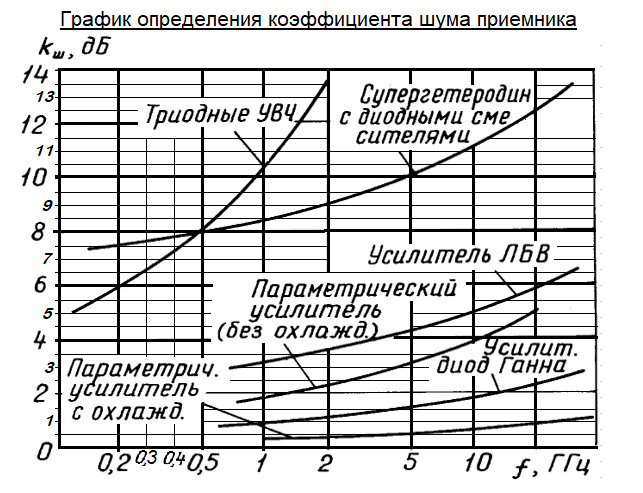

### Перевод коэффицента шума из дБ в разы
$$
k_{ш,дБ} = 10 ∙ lg(k_ш)
$$

$k_{ш} \text{ - коэффицент шума}$

In [7]:
#определяеться по рисунку
k_sh_db = float(0.3)
k_sh = 10**(k_sh_db/10)
print("Коэффицент шума: " + str(k_sh))

Коэффицент шума: 1.0715193052376064


## Коэффицент потерь энергии

Аналогичной формулой вычисляеться и значения результирующего коэффициента потерь энергии при обработке сигналов и прохождении всех трактов радиолокационной системы 

In [8]:

a_p_db = float(13)
a_p = 10**(a_p_db/10)
print("Коэффицент потерь: " + str(a_p))

Коэффицент потерь: 19.952623149688797


### Вероятность (условная) ложной тревоги

In [9]:
#ввод исходных данных
D=float(0.495)
F=float(0.00001)

### Обнаружение сигнала с неизвестной начальной фазой

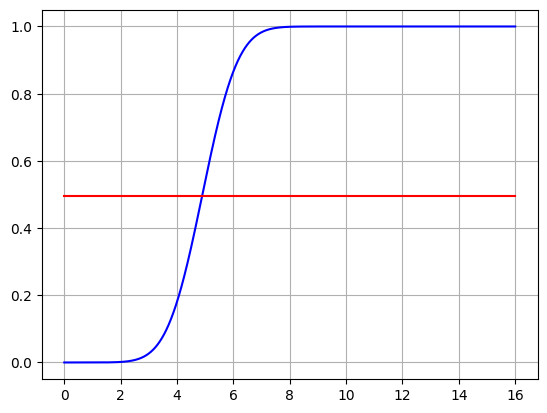

отношение сигнал/шум = 4.89


In [10]:
from numpy import sqrt, log, exp
from marcumq import marcumq

#общие переменные
z_0n = sqrt(-2*log(F))

q_0 = 0

xF = [i/10000 for i in range(1, 160000)]
yF = []
for q_000 in range(1, 160000):
    q = q_000/10000
    result = 1.0 - marcumq(1.0, z_0n, q)
    yF.append(result)
    if (abs(D/(result) - 1) < 0.0001):
        q_0 = q
plt.plot(xF, yF, color="blue")

xD = [i for i in range(0, 17)]
yD = [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]
plt.grid()
plt.plot(xD, yD, label=f"D={D}", color="red")
plt.show()
print("отношение сигнал/шум = " + str(q_0))
q_0 = 4.86 #скоректированное значение

### Обнаружение сигнала с неизвестными начальной фазой и амплитудой 

In [ ]:
from numpy import sqrt
q_0 = 0
xF = [i/1000 for i in range(1, 16000)]
yF = []
for q in range(1, 16000):
    q = q/1000
    step = 1/(1+(0.5*q*q))
    yF.append(F**step)
    if (q > 4) and abs(D/(F**step) - 1) < 0.0001:
        q_0 = q
plt.plot(xF, yF, label="D(fi, A)", color="blue")
xD = [i for i in range(0, 17)]
yD = [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]
plt.grid()
plt.plot(xD, yD, label=f"D={D}", color="red")
plt.show()
print("отношение сигнал/шум = " + str(q_0))

#### <span style="color:red">После нахождения значения график требуеться выключить!</span>

## Расчитаем максимальную дальность обнаружения без учета затухания по формуле:
$$
r_{max0} = ^4\sqrt{\frac {2 ∙ p_{ср} ∙ t_н ∙ G_m ∙ \sigma ∙ A_{max прм}}{(4\pi)^2 ∙ a_п ∙ q_0^2 ∙ k_ш ∙ k ∙ T}}
$$

$$
P_{cp} - \text{средняя мощность излучения генерируемого сигнала за время наблюдения}\\
t_н - \text{время наблюдения, отраженного от воздушного объекта сигнала}\\
G_m - \text{Максимальлное значение коэффицента усиления передающей антены}\\
A_{max прм} - \text{эффективная площадь приемной антены}\\
\delta - \text{эффективная площадб рассеивания воздушного объекта}\\
a_n - \text{результирующий коэффицент потерь при обработке сигналов}\\
q_0^2 - \text{значение отношения сигнал\шум}\\
k = 1.38*10^{-23}[\frac {Дж}{К}] - \text{постоянная Больцмана}
$$

In [11]:
k = 1.38/(10**23) #постоянная больцмана

Qr = 3.7 #эффективной площади рассеивания ВО (эпр)

T = -2 + 273 #Температура откружающей среды в Кельвинах

r_max_0 = sqrt(sqrt((2*P_cp*t_n*G_m*Qr*A_max_pered)/((4*pi)*(4*pi)*a_p*q_0*q_0*k_sh*k*T))) 
print( "Максимальная дальность обнаружения без потерь: " + str(r_max_0/1000) + " км")

Максимальная дальность обнаружения без потерь: 1010.5933343010481 км


## <span style="color:blue">Построение диаграммы направленности с учетом максимальной дальности</span>  

<p>Общее затухание потери на всей трассе вычисляется по формуле:</p>
$$
a_{зп} = δ_{пг} ∙ 2 ∙ r
$$


С учётом затухания радиоволн в атмосфере дальность радиолокационного обнаружения определяется выражением по другой формуле:
$$
r_{max} = r_{max0} * 10^{-0.05 ∙ δ_{пг} ∙ r_{max}}
\\r_{max} \text{ - максимальная дальность обнаружения без потерь}
\\δ_{пг} \text{ = 0.14 дб/км - удельное затухание радиоволн в атмосфере}
\\
\\F(r_{max}) = r_{max} - r_{max0} ∙ 10^{-0.05 ∙ δ_{пг} ∙ r_{max}}
$$

### <span style="color:blue">Найдите по графику искомую дальность и введите найденное значение ниже</span>

258.288


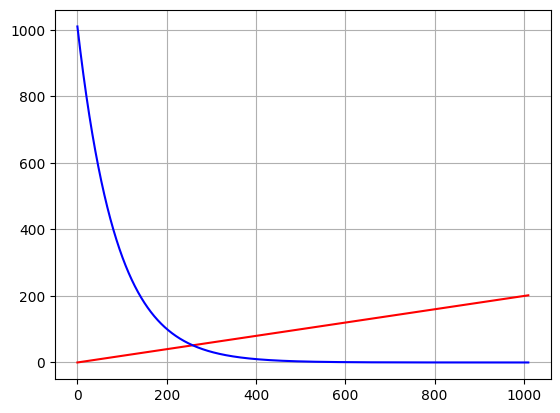

максимальную дальность в километрах 258.288


In [12]:
%matplotlib inline
Q_pg = float(0.1) #дБ/км
r_station = int(r_max_0/1000)

xf1 = []
yf1 = []

for r in range(0, r_station*1000):
    xf1.append(r/1000)
    yf1.append(Q_pg * 2 * r/1000)
plt.plot(xf1, yf1, color="red")

xf2 = []
yf2 = []
for r in range(0, r_station*1000):
    xf2.append(r/1000)
    yf2.append(r_max_0 * 10**(-0.05*Q_pg*r/1000)/1000)
plt.plot(xf2, yf2, color="blue")

r_max = 0
for i in range(100000, int(r_station*1000*0.6)): #в диапозоне от 100 км до ок.600 км
    if abs(yf1[i] - yf2[i]) < 0.0005: #играться с точностью если нет значений
        print(xf2[i])
        r_max = xf2[i]
plt.grid()
plt.show()
print("максимальную дальность в километрах " + str(r_max))

In [13]:
print("Разница дальностей: " + str(r_max_0/(r_max*1000)))

Разница дальностей: 3.9126608061584283


#### <span style="color:red">После нахождения значения график требуеться выключить!</span>

### Зона обнаружения РЛС в вертикальной плоскости в свободном пространстве

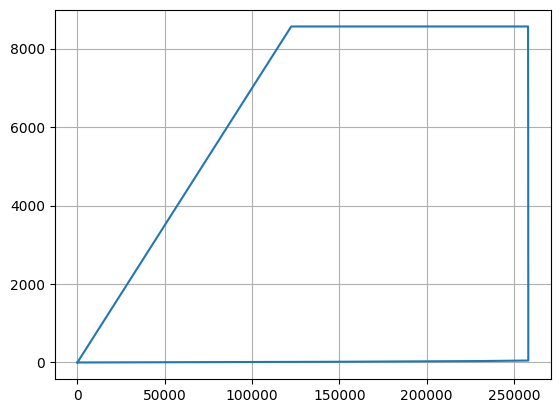

In [14]:
x_max=[]
y_max=[]
for i in range(0, len(x), 1):              
    x_max.append(x[i]*r_max*1000)
    y_max.append(y[i]*r_max*1000)
plt.plot(x_max, y_max)
plt.grid()
plt.show()

## <span style="color:blue">Построение зоны обнаружения наземной обзорной РЛС с учётом отражений от плоской подстилающей поверхности и рефракции радиоволн<span>
 
На процесс распросранения электромагнитных волн (ЭМВ) вблизи поверхности Земли оказывают влияние следующие факторы:
• наличие переотражений от этой поверхности;
• сферичность земной поверхности;
• влияние неровностей на поверхности .
Наличие переотражений от земной поверхности учитывается введением в рассмотрение интерференционного множителя |$\dot{Ф}(θ)$| земли (ИМЗ) который в общем случае носит комплексный характер, зависит от высоты h^` подъема излучателя (антенны), коэффициента ($\dot{R}_r$) ̇ (коэффициент Френеля) отражения плоской волны от плоской границы раздела двух сред, угла θ возвышения точки наблюдения (воздушного объекта), а также вида поляризации радиоволны и характера подстилающей поверхности.
Интерференционный множитель земли для горизонтально поляризованной плоской волны вычисляется следующей функцией:
$$
|\dot{Ф}(θ)|=\sqrt{1 + |\dot{R}_r|^2 + 2 ∙ |\dot{R}_r| ∙ \cos(2 ∙ k_0 ∙ h^` ∙ \sin{θ} + β_г)}
$$
    
$$
k_0 = \frac{2\pi}{λ} - \text{волновое число}\\
λ - \text{длина волны}\\
\dot{R}_r - \text{коэффициент отражения для горизонтальной поляризации ЭМВ}\\
β_г - \text{аргумент коэффициента } \dot{R}_r
$$

### Коэффициент отражения для горизонтальной поляризации плоской волны

$$
\dot{R}_r = \frac {\dot{μ}_{a2}\dot{k}_1\sin{θ} - \dot{μ}_{a1}\sqrt{\dot{k}_2^2-\dot{k}_1^2(\cos(θ))^2}}{\dot{μ}_{a2}\dot{k}_1\sin{θ} + \dot{μ}_{a1}\sqrt{\dot{k}_2^2-\dot{k}_1^2(\cos(θ))^2}}
$$

$$
\dot{k} = ω * \sqrt{\dot{ε}_a * μ_a} - \text{комплексный коэффициент фазы}\\
\dot{ε}_a = ε_a - j * \frac{σ}{ω} - \text{комплексная абсолютная диэлектрическая проницаемость среды}\\
ε_a = ε_0 - ε - \text{абсолютная диэлектрическая проницаемость среды}\\
ε - \text{относительная диэлектрическая проницаемость среды}\\
ε_1 = 1 - \text{относительная диэлектрическая проницаемость атмосферы}\\
ε_2 = 50 - \text{относительная диэлектрическая проницаемость подстилающей поверхности}\\
ε_0 = \frac{1}{36 * \pi} * 10^{-9} - \frac{Ф}{М} \text{электрическая постоянная вакуума}\\
μ - \text{абсолютная магнитная проницаемость среды}\\
μ_{a1} = 1 - \text{относительная магнитная проницаемость среды}\\
μ_{a2} = 1 - \text{относительная магнитная проницаемость среды подстилающей поверхности}\\
μ_0 = 4 * \pi * 10^{-7} [\frac{Г}{М}] -  \text{магнитная постоянная вакуума} \\
ω = 2 * \pi * \frac{3 * 10^8}{λ} - \text{круговая частота}\\
σ = 2 - \text{удельная проводимость среды} \frac{См}{м}
$$

### График интерференционного множителя Земли

$$
|\dot{Ф}(θ)|=\sqrt{1 + |\dot{R}_r|^2 + 2 ∙ |\dot{R}_r| ∙ \cos(2 ∙ k_0 ∙ h^` ∙ \sin{θ} + β_г)}
$$
---


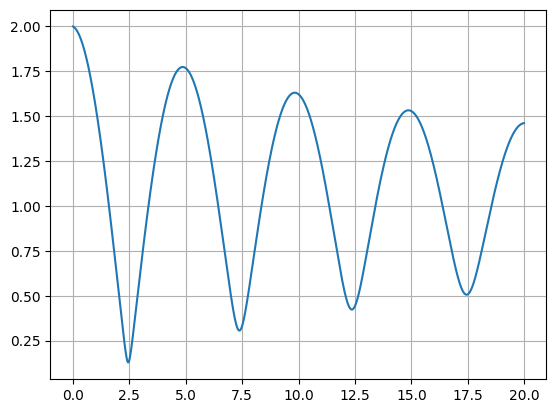

In [15]:
%matplotlib inline
from numpy import sqrt, cos, degrees
h = 7 # столбец " K "
j = -1
#Удельная проводимость среды
qr2 = 0.1 # столбец " AA "
#Волновое число
k0 = (2*pi)/ly
#Круговая частота
w_round = (2 * pi * 3*10**8)/ly
#Относительная магнитная проницаемость среды
e_0 = (10**(-9))/(36 * pi)
#Магнитная постоянная вакуума
u_0 = 4*pi*10**(-7)
#Относительная диэлектрическая проницаемость атмосферы
e_1 = 1
#Относительная диэлектрическая проницаемость подстилающей поверхности
e_2 = 80 # столбец " Z "
#Абсолютная диэлектрическая проницаемость атмосферы
e_a1 = e_0 * e_1
#Абсолютная диэлектрическая проницаемость подстилающей поверхности
e_a2 = e_0 * e_2
#Удельная проводимость атмосферы
qr1 = 0 
#Относительная магнитная проницаемость атмосферы
u_a1 = 1
#Относительная магнитная проницаемость подстилающей поверхности
u_a2 = 1
#Абсолютная магнитная проницаемость атмосферы
u_a1A = u_0*u_a1
#Абсолютная магнитная проницаемость подстилающей поверхности
u_a2A = u_0*u_a2
#Комплексная диэлектрическая проницаемость атмосферы
dot_e_a1 = e_a1 - j * (qr2/w_round)
dot_e_a2 = e_a2 - j * (qr2/w_round)

#Комплексный коэффициент фазы
dot_k1 = w_round  * sqrt(dot_e_a1 * u_a1A)
dot_k2 = w_round  * sqrt(dot_e_a2 * u_a2A)



xf0=[]
yf0=[]
pravka = radians(1)
B_r = 0 #вертикальная =  B_r = radians(dot_R_r)
#B_r = pi #горизонталная  =  B_r = radians(360)-radians(dot_R_r)

for e_g  in range(int(e_min*10000), int(e_max*10000)*5, 1):
    e = e_g/10000
    #для горизонтальной поляризации
    #dot_R =  (u_a2A*dot_k1*sin(e) - u_a1A*sqrt(dot_k2**2 - (dot_k1**2)*(cos(e)**2))/(u_a2A*dot_k1*sin(e) + u_a1A*sqrt(dot_k2**2 - (dot_k1**2)*(cos(e)**2))))
    #для вертикальной поляризации
    dot_R =  (dot_e_a2*dot_k1*sin(e) - dot_e_a1*sqrt(dot_k2**2 - (dot_k1**2)*(cos(e)**2))/(dot_e_a2*dot_k1*sin(e) + dot_e_a1*sqrt(dot_k2**2 - (dot_k1**2)*(cos(e)**2))))
    E = sqrt(1 + abs(dot_R)**2 + 2*abs(dot_R) * cos(2*k0*h*sin(e) + B_r))
    xf0.append(degrees(e))
    yf0.append(E)
plt.plot(xf0, yf0)
plt.grid()
plt.show()

### Диаграмма направленности антенны в вертикальной плоскости с учетом отражений от плоской подстилающей поверхности
$$
Dn(θ)=r_{max} ∙ F(θ)∙|\dot{Ф} ̇(θ)|
$$

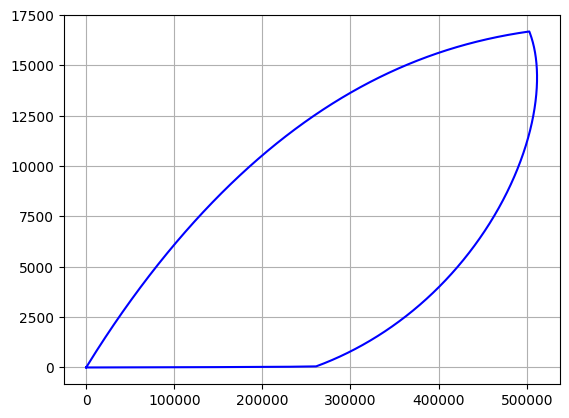

In [16]:

x_maxE = []
y_maxE = []
i = 0
for e_g  in range(0, 90000, 1):
    e = radians(e_g/1000)
    dot_R_r = (u_a2*dot_k1*sin(e) - u_a1*sqrt(dot_k2*dot_k2 - dot_k1*dot_k1*cos(e)*cos(e)))/(u_a2*dot_k1*sin(e) + u_a1*sqrt(dot_k2*dot_k2 - dot_k1*dot_k1*cos(e)*cos(e)))
    B_r = 2*pi+dot_R_r-(u_a2*dot_k1*sin(e) - u_a1*sqrt(dot_k2*dot_k2 + dot_k1*dot_k1*cos(e)*cos(e)))/(u_a2*dot_k1*sin(e) - u_a1*sqrt(dot_k2*dot_k2 - dot_k1*dot_k1*cos(e)*cos(e)))
    E = sqrt(1 + dot_R_r*dot_R_r + 2*abs(dot_R_r) * cos(2*k0*h*sin(e) + B_r))
    
    if 0 < e and e < radians(90):
        x_t=(1 - ((e_min-e)/e))*cos(e)*r_max*E
        if x_t > 0 and e != e_min:
            x_maxE.append(x_max[i]*E)
            y_maxE.append(y_max[i]*E)
            i+=1

plt.plot(x_maxE, y_maxE, color='blue')
plt.grid()
plt.show()

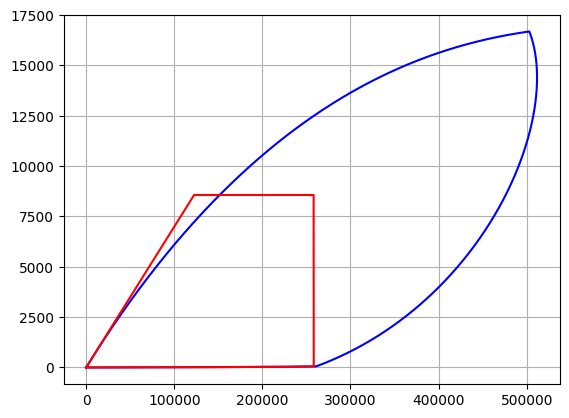

In [17]:
plt.plot(x_maxE, y_maxE, color='blue')
plt.plot(x_max, y_max, color='red')
plt.grid()
plt.show()

## <span style="color:blue">Зона обнаружения РЛС в декартовой системе координат с учётом влияния Земли и без его учёта <span>
    
Форма интерференционного множителя Земли, рассчитанного с помощью функции для заданных выше значений.
Изменение интерференционного множителя Земли (ИМЗ) |$\dot{Ф}(θ)$|, который в общем случае носит комплексный характер

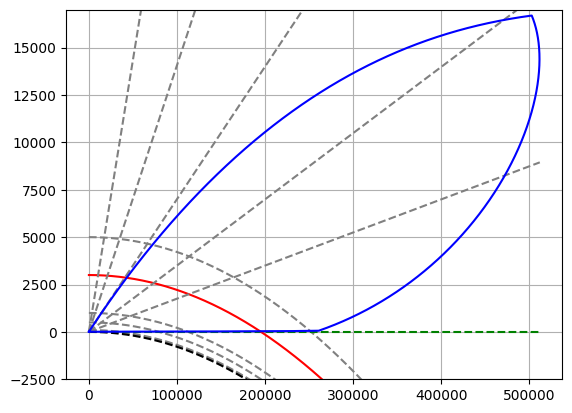

In [26]:
%matplotlib inline
from numpy import tan
x_maxEh = []
y_maxEh = []
x=[]
y3=[]
y4=[]
y1g=[]
x1g=[]
y2g=[]
x2g=[]
y4g=[]
x4g=[]
y8g=[]
x8g=[]
y16g=[]
x16g=[]
y50=[]
y100=[]
y500=[]
y1000=[]
y5000=[]
view_height = int(3000)
yVH = []

for i in range(0, len(x_maxE), 1):              
    x_maxEh.append(x_maxE[i]+h)
    y_maxEh.append(y_maxE[i]+h)

R0 = 6370000
# столбец " AB "
dn_dz = -0.00000005
RE = R0/(1+R0*dn_dz)

alt_max = 0
long_max = 0
for i in range(0, len(x_maxE), 1):   
    if alt_max < y_maxE[i]+h:
        alt_max=y_maxE[i]+h+500
    if long_max < x_maxE[i]+h:
        long_max = x_maxE[i]+h+500

for xt in range(0, int(long_max), 10):
    x.append(xt)
    y3.append(-(xt*xt)/(2*R0))
    y4.append(-(xt*xt)/(2*RE))

    y50.append(50-(xt*xt)/(2*R0))
    y100.append(100-(xt*xt)/(2*R0))
    y500.append(500-(xt*xt)/(2*R0))
    y1000.append(1000-(xt*xt)/(2*R0))
    y5000.append(5000-(xt*xt)/(2*R0))

    yVH.append(view_height-(xt*xt)/(2*R0))
    if tan(radians(1))*xt+h < alt_max :
        x1g.append(xt)
        y1g.append(tan(radians(1))*xt+h)
    if tan(radians(2))*xt+h < alt_max:
        x2g.append(xt)
        y2g.append(tan(radians(2))*xt+h)
    if tan(radians(4))*xt+h < alt_max:
        x4g.append(xt)
        y4g.append(tan(radians(4))*xt+h)
    if tan(radians(8))*xt+h < alt_max:
        x8g.append(xt)
        y8g.append(tan(radians(8))*xt+h)
    if tan(radians(16))*xt+h < alt_max:
        y16g.append(tan(radians(16))*xt+h)
        x16g.append(xt)
        
plt.plot(x, y50, color='grey', linestyle='--')
plt.plot(x, y100, color='grey', linestyle='--')
plt.plot(x, y500, color='grey', linestyle='--')
plt.plot(x, y1000, color='grey', linestyle='--')
plt.plot(x, y5000, color='grey', linestyle='--')
plt.plot([0, long_max], [h, h], color='green', label=" Высота антены", linestyle='--') 
plt.plot(x, y3, color='black', label="Земля (без рефракции)", linestyle='--') 
plt.plot(x, yVH, color='red', label=(str(view_height)+"м"))   
plt.plot(x1g, y1g, color='grey', label="Сетка углов", linestyle='--')
plt.plot(x2g, y2g, color='grey', linestyle='--')
plt.plot(x4g, y4g, color='grey', linestyle='--')
plt.plot(x8g, y8g, color='grey', linestyle='--')
plt.plot(x16g, y16g, color='grey', linestyle='--')
plt.plot(x_maxEh, y_maxEh, color='blue', label=" Зона локации")
plt.ylim(-2500, 17000) #обрезка по y
plt.grid()
plt.show()

## Продемонстрируйте преподавателю полученный график и результаты вычислений и сделайте вывод по ним.

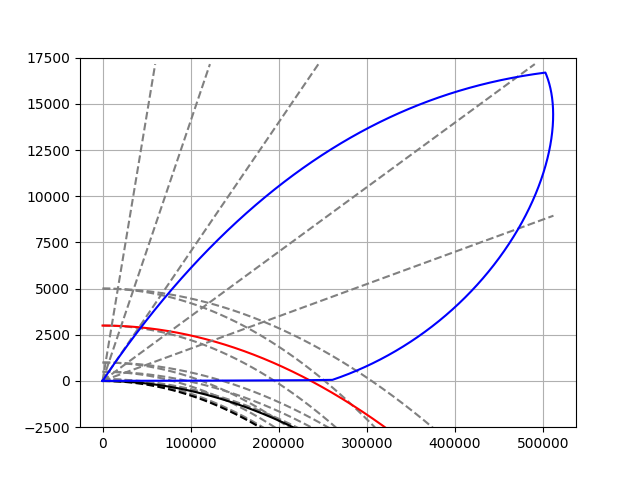

In [27]:
%matplotlib widget
from numpy import tan
x_maxEh = []
y_maxEh = []
x=[]
y3=[]
y4=[]
y1g=[]
x1g=[]
y2g=[]
x2g=[]
y4g=[]
x4g=[]
y8g=[]
x8g=[]
y16g=[]
x16g=[]

y50=[]
y100=[]
y500=[]
y1000=[]
y5000=[]

y50R=[]
y100R=[]
y500R=[]
y1000R=[]
y5000R=[]

view_height = int(3000)
yVH = []
yVH0 = []

for i in range(0, len(x_maxE), 1):              
    x_maxEh.append(x_maxE[i]+h)
    y_maxEh.append(y_maxE[i]+h)

R0 = 6370000
# столбец " AB "
dn_dz = -0.00000005
RE = R0/(1+R0*dn_dz)

alt_max = 0
long_max = 0
for i in range(0, len(x_maxE), 1):   
    if alt_max < y_maxE[i]+h:
        alt_max=y_maxE[i]+h+500
    if long_max < x_maxE[i]+h:
        long_max = x_maxE[i]+h+500

for xt in range(0, int(long_max), 10):
    x.append(xt)
    y3.append(-(xt*xt)/(2*R0))
    y4.append(-(xt*xt)/(2*RE))

    y50.append(50-(xt*xt)/(2*R0))
    y100.append(100-(xt*xt)/(2*R0))
    y500.append(500-(xt*xt)/(2*R0))
    y1000.append(1000-(xt*xt)/(2*R0))
    y5000.append(5000-(xt*xt)/(2*R0))

    y50R.append(50-(xt*xt)/(2*RE))
    y100R.append(100-(xt*xt)/(2*RE))
    y500R.append(500-(xt*xt)/(2*RE))
    y1000R.append(1000-(xt*xt)/(2*RE))
    y5000R.append(5000-(xt*xt)/(2*RE))

    yVH0.append(view_height-(xt*xt)/(2*R0))
    yVH.append(view_height-(xt*xt)/(2*RE))
    if tan(radians(1))*xt+h < alt_max :
        x1g.append(xt)
        y1g.append(tan(radians(1))*xt+h)
    if tan(radians(2))*xt+h < alt_max:
        x2g.append(xt)
        y2g.append(tan(radians(2))*xt+h)
    if tan(radians(4))*xt+h < alt_max:
        x4g.append(xt)
        y4g.append(tan(radians(4))*xt+h)
    if tan(radians(8))*xt+h < alt_max:
        x8g.append(xt)
        y8g.append(tan(radians(8))*xt+h)
    if tan(radians(16))*xt+h < alt_max:
        y16g.append(tan(radians(16))*xt+h)
        x16g.append(xt)


plt.plot(x, y50, color='grey', linestyle='--')
plt.plot(x, y100, color='grey', linestyle='--')
plt.plot(x, y500, color='grey', linestyle='--')
plt.plot(x, y1000, color='grey', linestyle='--')
plt.plot(x, y5000, color='grey', linestyle='--')

plt.plot(x, y50R, color='grey', linestyle='--')
plt.plot(x, y100R, color='grey', linestyle='--')
plt.plot(x, y500R, color='grey', linestyle='--')
plt.plot(x, y1000R, color='grey', linestyle='--')
plt.plot(x, y5000R, color='grey', linestyle='--')

plt.plot(x, y3, color='black', label="Земля (без рефракции)", linestyle='--') 
plt.plot(x, y4, color='black', label="Земля (с рефракции)")
plt.plot(x, yVH0, label=(str(view_height)+"м"), color='grey', linestyle='--')   
plt.plot(x, yVH, color='red', label=(str(view_height)+"м"))  
plt.plot(x1g, y1g, color='grey', label="Сетка углов", linestyle='--')
plt.plot(x2g, y2g, color='grey', linestyle='--')
plt.plot(x4g, y4g, color='grey', linestyle='--')
plt.plot(x8g, y8g, color='grey', linestyle='--')
plt.plot(x16g, y16g, color='grey', linestyle='--')
plt.plot(x_maxEh, y_maxEh, color='blue', label=" Зона локации")
plt.ylim(-2500, 17500) #обрезка по y
plt.grid()
plt.show()

In [ ]:

import matplotlib.pyplot as plt
from numpy import cos, sin, radians

x_rounds = []
y_rounds = []
point_round = []
# Введите кол-во точек пересечения
n_point = int(2)
# введите точки пересечения справа на лево
point_round = [188, 26] # эти значения приодятся дальше при выполнении курсовой работы

if n_point == 1:
    for p in range(0, 360, 10):
        x_rounds.append(point_round[0]*cos(radians(p)))
        y_rounds.append(point_round[0]*sin(radians(p)))
    plt.plot(x_rounds, y_rounds, color='red') 
elif n_point == 2 or n_point == 3:
    if n_point ==3:
        point_round[1] = point_round[2]
    for r in range(0, (point_round[0] - point_round[1]), 1):
        x_rounds = []
        y_rounds = []
        for p in range(0, 360, 10):
            x_rounds.append((point_round[1]+r)*cos(radians(p)))
            y_rounds.append((point_round[1]+r)*sin(radians(p))) 
        x_rounds.append((point_round[1]+r)*cos(radians(0)))
        y_rounds.append((point_round[1]+r)*sin(radians(0))) 
        plt.plot(x_rounds, y_rounds, color='red')    
elif n_point == 4:  
    for r in range(0, point_round[0]-point_round[1], 1):
        x_rounds = []
        y_rounds = []
        for p in range(0, 360, 10):
            x_rounds.append((point_round[1]+r)*cos(radians(p)))
            y_rounds.append((point_round[1]+r)*sin(radians(p))) 
        x_rounds.append((point_round[1]+r)*cos(radians(0)))
        y_rounds.append((point_round[1]+r)*sin(radians(0))) 
        plt.plot(x_rounds, y_rounds, color='red') 
    for r in range(0, point_round[2]-point_round[3], 1):
        x_rounds = []
        y_rounds = []
        for p in range(0, 360, 10):
            x_rounds.append((point_round[3]+r)*cos(radians(p)))
            y_rounds.append((point_round[3]+r)*sin(radians(p)))
        x_rounds.append((point_round[3]+r)*cos(radians(0)))
        y_rounds.append((point_round[3]+r)*sin(radians(0)))
        plt.plot(x_rounds, y_rounds, color='red')  
        plt.axis('square')
        plt.show()